In [146]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
from tqdm import tqdm as tqdm

100%|██████████| 6/6 [00:08<00:00,  1.44s/it]


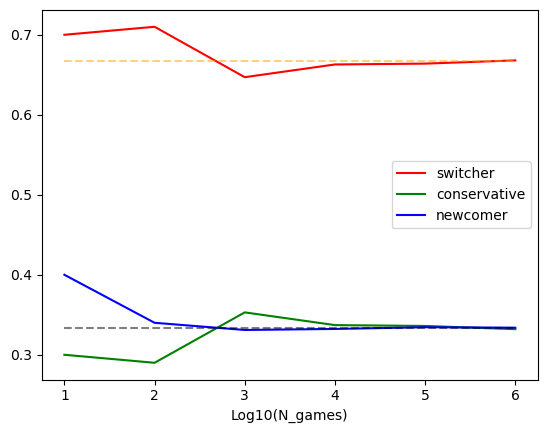

In [156]:
N_games = np.logspace(1, 6, 6)
switcher_record = np.zeros(len(N_games))
conservative_record = np.zeros(len(N_games))
newcomer_record = np.zeros(len(N_games))

for i in tqdm(range(len(N_games))):
    newcomer_counts=0
    conservative_counts=0
    switcher_counts=0
    for j in range(int(N_games[i])):
        N_doors = 3
        doors = np.zeros(N_doors)
        car_idx = rd.randint(0,2)
        doors[car_idx] = 1

        first_pick = rd.randint(0,2)
        valid_doors = np.delete(np.arange(0,N_doors), [car_idx, first_pick])
        presenter_idx = rd.choice(valid_doors)
        switcher_idx = rd.choice(np.delete(np.arange(0,N_doors),[first_pick, presenter_idx]))
        conservative_idx = first_pick
        newcomer_idx = rd.randint(0,2)

        if switcher_idx == car_idx: switcher_counts += 1
        if conservative_idx == car_idx: conservative_counts += 1
        if newcomer_idx == car_idx: newcomer_counts += 1
        switcher_record[i] = switcher_counts/N_games[i]
        conservative_record[i] = conservative_counts/N_games[i]
        newcomer_record[i] = newcomer_counts/N_games[i]

x=np.ones(len(N_games))
plt.plot(np.log10(N_games), switcher_record, c='red', label='switcher')
plt.plot(np.log10(N_games), conservative_record, c='green', label='conservative')
plt.plot(np.log10(N_games), newcomer_record, c='blue', label='newcomer')
plt.plot(np.log10(N_games), x/3, c='black', ls='dashed', alpha=0.5)
plt.plot(np.log10(N_games), x*2/3, c='orange', ls='dashed', alpha=0.5)
#plt.xscale('log')
plt.xlabel('Log10(N_games)')
plt.legend()
plt.show()


# Trash

In [ ]:
print('first pick', first_pick)
print('presenter pick', presenter_idx)
print('switcher pick', switcher_idx)
print('conservative pick', conservative_idx)
print('newcomer pick', newcomer_idx)
print('car', car_idx)

if switcher_idx == car_idx: print('switcher wins!')
if conservative_idx == car_idx: print('conservative wins!')
if newcomer_idx == car_idx: print('newcomer wins!')